In [2]:
pip install tensorflow==2.19.0


In [4]:
pip install --upgrade pip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 93.5 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


In [22]:

!pip install -q scikit-learn seaborn matplotlib opencv-python Pillow

import tensorflow as tf
print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [23]:
import os
import zipfile

# ── Step 1: List everything in /content
print('Files currently in /content:')
for item in os.listdir('/content'):
    full = os.path.join('/content', item)
    if os.path.isfile(full):
        size = round(os.path.getsize(full) / (1024*1024), 2)
        print('  FILE  :', item, '  Size:', size, 'MB')
    else:
        print('  FOLDER:', item)

# ── Step 2: Find the zip file automatically
zip_file = None
for item in os.listdir('/content'):
    if item.lower().endswith('.zip'):
        zip_file = os.path.join('/content', item)
        print('\nFound zip file:', zip_file)
        break

if zip_file is None:
    print('\nNo zip file found in /content')
    print('Please upload your zip using the folder icon on the left sidebar')
else:
    # ── Step 3: Extract
    extract_to = '/content/plantdata'
    os.makedirs(extract_to, exist_ok=True)
    print('Extracting... please wait...')
    with zipfile.ZipFile(zip_file, 'r') as z:
        z.extractall(extract_to)
    print('Extraction complete!')

    # ── Step 4: Show extracted structure
    print('\nExtracted structure:')
    for root, dirs, files in os.walk(extract_to):
        level = root.replace(extract_to, '').count(os.sep)
        indent = '  ' * level
        print(indent + os.path.basename(root) + '/')
        if level >= 2:
            break

Files currently in /content:
  FOLDER: .config
  FOLDER: outputs
  FOLDER: plantdata
  FILE  : ml dataset final .zip   Size: 328.14 MB
  FOLDER: sample_data

Found zip file: /content/ml dataset final .zip
Extracting... please wait...
Extraction complete!

Extracted structure:
plantdata/
  PlantVillage/
    Tomato_Leaf_Mold/


In [24]:
import os

# ── Auto-find PlantVillage folder
DATA_DIR = None

for root, dirs, files in os.walk('/content/plantdata'):
    # Check if this folder has disease-class subfolders
    subfolders = [d for d in dirs if os.path.isdir(os.path.join(root, d))]
    disease_keywords = ['Tomato', 'Potato', 'Pepper', 'Apple', 'Corn', 'Grape']
    has_disease_folders = any(
        any(kw in sf for kw in disease_keywords) for sf in subfolders
    )
    if has_disease_folders and len(subfolders) > 3:
        DATA_DIR = root
        break

if DATA_DIR:
    class_folders = sorted([
        d for d in os.listdir(DATA_DIR)
        if os.path.isdir(os.path.join(DATA_DIR, d))
    ])
    print('Dataset found at:', DATA_DIR)
    print('Number of classes:', len(class_folders))
    print()
    total_images = 0
    for cls in class_folders:
        cls_path = os.path.join(DATA_DIR, cls)
        n = len([
            f for f in os.listdir(cls_path)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ])
        total_images += n
        print('  {:45s}  {:5d} images'.format(cls, n))
    print()
    print('Total images:', total_images)
else:
    print('ERROR: Could not find dataset folder automatically')
    print('Please set DATA_DIR manually below:')
    DATA_DIR = '/content/plantdata'   # <-- change this if needed
    print('DATA_DIR set to:', DATA_DIR)

Dataset found at: /content/plantdata/PlantVillage
Number of classes: 15

  Pepper__bell___Bacterial_spot                    997 images
  Pepper__bell___healthy                          1478 images
  Potato___Early_blight                           1000 images
  Potato___Late_blight                            1000 images
  Potato___healthy                                 152 images
  Tomato_Bacterial_spot                           2127 images
  Tomato_Early_blight                             1000 images
  Tomato_Late_blight                              1909 images
  Tomato_Leaf_Mold                                 952 images
  Tomato_Septoria_leaf_spot                       1771 images
  Tomato_Spider_mites_Two_spotted_spider_mite     1676 images
  Tomato__Target_Spot                             1404 images
  Tomato__Tomato_YellowLeaf__Curl_Virus           3208 images
  Tomato__Tomato_mosaic_virus                      373 images
  Tomato_healthy                                  1591 imag

In [25]:
import os

# Paths
OUTPUT_DIR      = '/content/outputs'
DATASET_BASE    = '/content/outputs/dataset'
MODEL_PATH      = '/content/outputs/best_model.keras'
TFLITE_PATH     = '/content/outputs/model.tflite'
REPORT_PATH     = '/content/outputs/report.txt'
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(DATASET_BASE, exist_ok=True)

# Image settings
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
SEED        = 42

# Split ratios
TRAIN_SPLIT = 0.70
VAL_SPLIT   = 0.15
TEST_SPLIT  = 0.15

# Model settings
DROPOUT     = 0.4
L2_REG      = 1e-4

# Phase 1: train head only
P1_EPOCHS   = 10
P1_LR       = 1e-3

# Phase 2: fine-tune
P2_EPOCHS   = 20
P2_LR       = 1e-4
UNFREEZE    = 30

# Callbacks
PATIENCE    = 5

# Augmentation for training images
AUG = dict(
    rotation_range     = 30,
    width_shift_range  = 0.15,
    height_shift_range = 0.15,
    shear_range        = 0.10,
    zoom_range         = 0.20,
    horizontal_flip    = True,
    vertical_flip      = True,
    brightness_range   = [0.75, 1.25],
    fill_mode          = 'reflect',
)

print('Config ready!')
print('Output folder:', OUTPUT_DIR)

Config ready!
Output folder: /content/outputs


In [26]:
import os
import json
import shutil
import random
import numpy as np
from sklearn.model_selection import train_test_split

random.seed(SEED)
np.random.seed(SEED)

# ── Collect all image paths and labels
CLASS_NAMES = sorted([
    d for d in os.listdir(DATA_DIR)
    if os.path.isdir(os.path.join(DATA_DIR, d))
])
NUM_CLASSES = len(CLASS_NAMES)

all_paths  = []
all_labels = []

for idx, cls in enumerate(CLASS_NAMES):
    cls_dir = os.path.join(DATA_DIR, cls)
    imgs = [
        os.path.join(cls_dir, f)
        for f in os.listdir(cls_dir)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]
    all_paths  += imgs
    all_labels += [idx] * len(imgs)

print('Total images collected:', len(all_paths))
print('Total classes         :', NUM_CLASSES)

# ── Save class names for inference later
with open(os.path.join(OUTPUT_DIR, 'class_names.json'), 'w') as f:
    json.dump(CLASS_NAMES, f, indent=2)

# ── Stratified split
val_frac = VAL_SPLIT / (TRAIN_SPLIT + VAL_SPLIT)

X_tv, X_test, y_tv, y_test = train_test_split(
    all_paths, all_labels,
    test_size=TEST_SPLIT, stratify=all_labels, random_state=SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv,
    test_size=val_frac, stratify=y_tv, random_state=SEED
)

print()
print('Train images:', len(X_train))
print('Val   images:', len(X_val))
print('Test  images:', len(X_test))

# ── Copy into folder structure (only if not already done)
splits = {
    'train': (X_train, y_train),
    'val'  : (X_val,   y_val),
    'test' : (X_test,  y_test),
}

already_done = os.path.exists(os.path.join(DATASET_BASE, 'train'))
if already_done:
    print('\nFolder structure already exists, skipping copy.')
else:
    print('\nCopying files into train/val/test folders...')
    for split_name, (paths, labels) in splits.items():
        for p, l in zip(paths, labels):
            dest = os.path.join(DATASET_BASE, split_name, CLASS_NAMES[l])
            os.makedirs(dest, exist_ok=True)
            shutil.copy2(p, dest)
        print('  Done:', split_name, '->', len(paths), 'images')

print('\nDone!')

Total images collected: 20638
Total classes         : 15

Train images: 14446
Val   images: 3096
Test  images: 3096

Folder structure already exists, skipping copy.

Done!


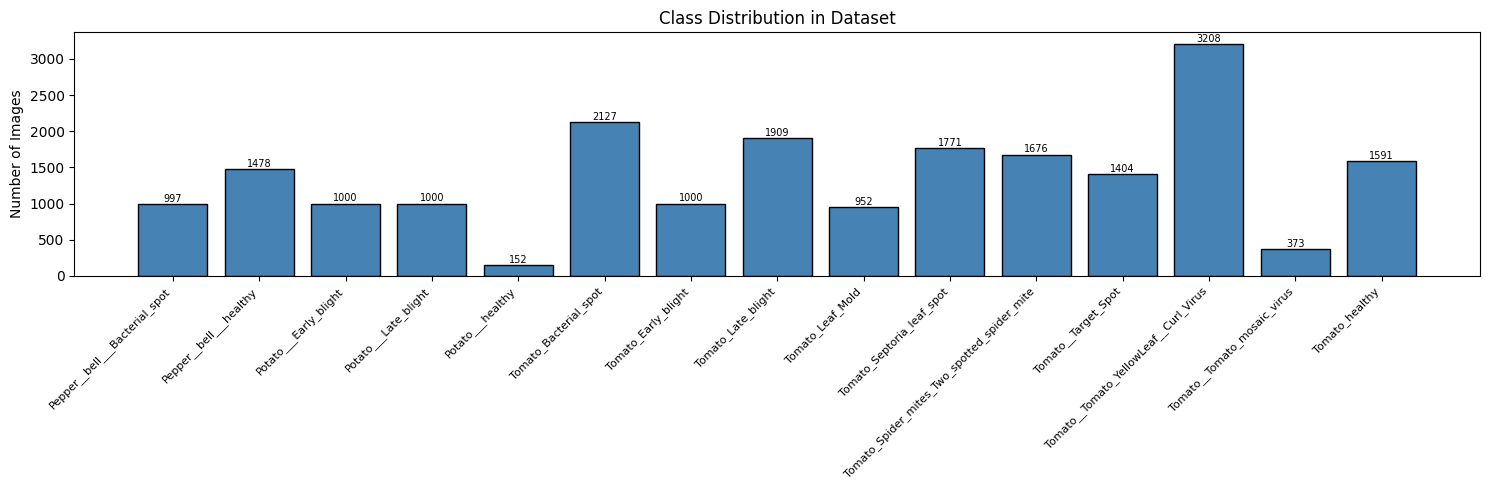

Saved: class_distribution.png


In [27]:
import matplotlib.pyplot as plt
import numpy as np
import os

counts = []
for cls in CLASS_NAMES:
    cls_dir = os.path.join(DATA_DIR, cls)
    n = len([
        f for f in os.listdir(cls_dir)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ])
    counts.append(n)

plt.figure(figsize=(max(14, NUM_CLASSES), 5))
bars = plt.bar(CLASS_NAMES, counts, color='steelblue', edgecolor='black')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.ylabel('Number of Images')
plt.title('Class Distribution in Dataset')
for bar, cnt in zip(bars, counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        str(cnt), ha='center', va='bottom', fontsize=7
    )
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'class_distribution.png'), dpi=120)
plt.show()
print('Saved: class_distribution.png')

Found 14446 images belonging to 15 classes.
Found 3096 images belonging to 15 classes.
Found 3096 images belonging to 15 classes.


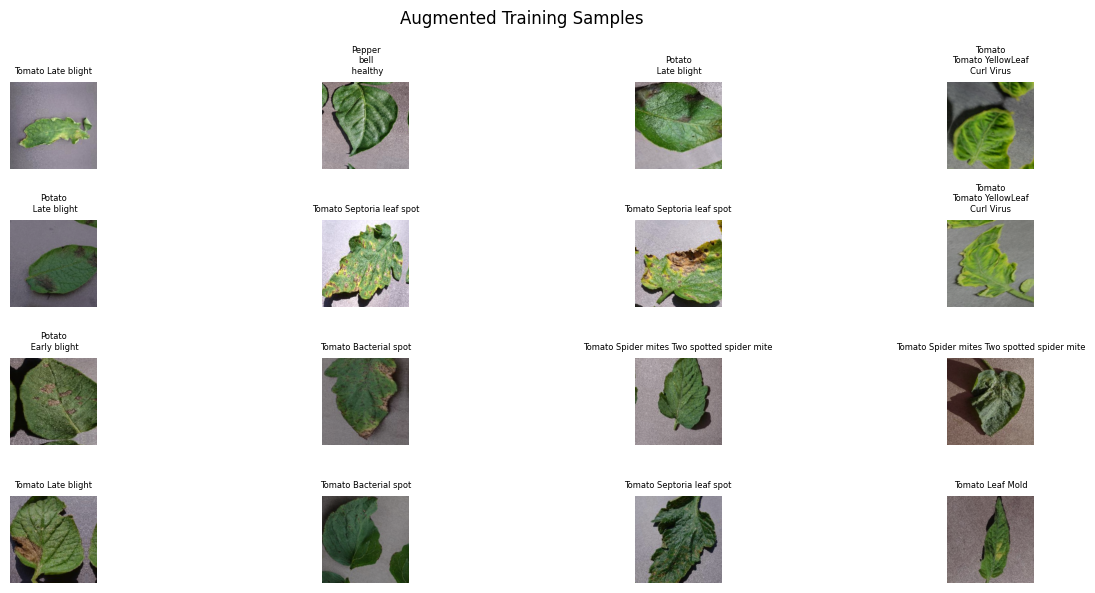

Generators ready!


In [28]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight

# Training generator (with augmentation)
train_datagen = ImageDataGenerator(**AUG)

# Val and test generators (no augmentation)
eval_datagen = ImageDataGenerator()

gen_args = dict(
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    classes     = CLASS_NAMES,
    seed        = SEED,
)

train_gen = train_datagen.flow_from_directory(
    os.path.join(DATASET_BASE, 'train'), shuffle=True, **gen_args)

val_gen = eval_datagen.flow_from_directory(
    os.path.join(DATASET_BASE, 'val'), shuffle=False, **gen_args)

test_gen = eval_datagen.flow_from_directory(
    os.path.join(DATASET_BASE, 'test'), shuffle=False, **gen_args)

# Class weights to handle imbalanced data
cw = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=y_train
)
CLASS_WEIGHTS = dict(enumerate(cw))

# Show sample augmented images
sample_imgs, sample_labels = next(train_gen)
plt.figure(figsize=(14, 6))
for i in range(min(16, len(sample_imgs))):
    ax = plt.subplot(4, 4, i + 1)
    plt.imshow(sample_imgs[i].astype('uint8'))
    lbl = CLASS_NAMES[np.argmax(sample_labels[i])]
    plt.title(lbl.replace('__', '\n').replace('_', ' '), fontsize=6)
    plt.axis('off')
plt.suptitle('Augmented Training Samples', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'sample_images.png'), dpi=120)
plt.show()
print('Generators ready!')

In [29]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input

def build_model(num_classes, freeze_base=True):
    # Input layer
    inputs = tf.keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

    # Preprocessing inside the model
    x = tf.keras.layers.Lambda(
        lambda img: preprocess_input(tf.cast(img, tf.float32))
    )(inputs)

    # Pretrained backbone
    base = EfficientNetB3(
        include_top = False,
        weights     = 'imagenet',
        input_tensor= x,
        pooling     = None
    )
    base.trainable = not freeze_base

    # Classification head
    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(DROPOUT)(x)
    x = layers.Dense(
        512, activation='relu',
        kernel_regularizer=regularizers.l2(L2_REG)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(DROPOUT / 2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs=base.input, outputs=outputs)
    return model

# Build with frozen base
model = build_model(NUM_CLASSES, freeze_base=True)

# Count parameters
total_params     = model.count_params()
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
print('Model built successfully!')
print('Total params    :', f'{total_params:,}')
print('Trainable params:', f'{trainable_params:,}')
print('Base model      : EfficientNetB3 (pretrained on ImageNet)')

Model built successfully!
Total params    : 11,586,366
Trainable params: 798,735
Base model      : EfficientNetB3 (pretrained on ImageNet)


PHASE 1 — Training classification head (base is frozen)
Epochs: 10   LR: 0.001
--------------------------------------------------
Epoch 1/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 535ms/step - accuracy: 0.6064 - loss: 1.3944 - top3_acc: 0.8273
Epoch 1: val_accuracy improved from None to 0.86757, saving model to /content/outputs/best_model_phase1.keras

Epoch 1: finished saving model to /content/outputs/best_model_phase1.keras
452/452 ━━━━━━━━━━━━━━━━━━━━ 326s 615ms/step - accuracy: 0.7016 - loss: 1.0303 - top3_acc: 0.9013 - val_accuracy: 0.8676 - val_loss: 0.5136 - val_top3_acc: 0.9751 - learning_rate: 0.0010
Epoch 2/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 470ms/step - accuracy: 0.7832 - loss: 0.7165 - top3_acc: 0.9533
Epoch 2: val_accuracy improved from 0.86757 to 0.86983, saving model to /content/outputs/best_model_phase1.keras

Epoch 2: finished saving model to /content/outputs/best_model_phase1.keras
452/452 ━━━━━━━━━━━━━━━━━━━━ 221s 489ms/step - accuracy: 0.7939 - loss: 0.6934 - top3_acc: 0.9

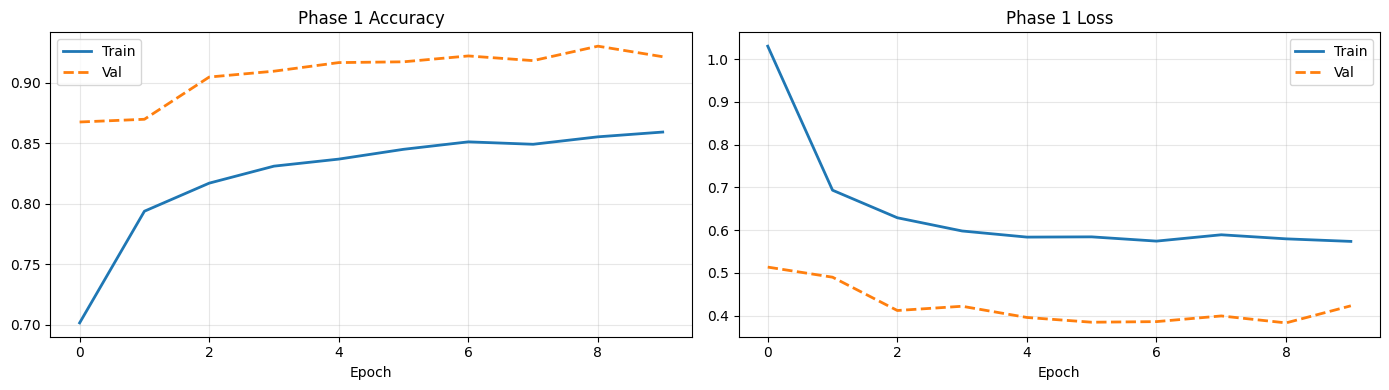

Phase 1 complete!
Val Accuracy: 93.02 %
Val Top-3   : 99.22 %


In [ ]:
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import optimizers
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping,
    ReduceLROnPlateau, CSVLogger
)

# ---------------- CALLBACKS ----------------
def get_callbacks(phase):
    ckpt_path = MODEL_PATH.replace('.keras', '_phase' + str(phase) + '.keras')
    return [
        ModelCheckpoint(
            filepath=ckpt_path,
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        ),
        EarlyStopping(
            monitor='val_accuracy',
            patience=PATIENCE,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.3,
            patience=3,
            min_lr=1e-7,
            verbose=1
        ),
        CSVLogger(os.path.join(OUTPUT_DIR, 'log_phase' + str(phase) + '.csv'))
    ]

# ---------------- PLOT FUNCTION ----------------
def plot_history(history, phase):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Accuracy
    axes[0].plot(history.history['accuracy'], label='Train', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Val', linewidth=2, linestyle='--')
    axes[0].set_title('Phase ' + str(phase) + ' Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Loss
    axes[1].plot(history.history['loss'], label='Train', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Val', linewidth=2, linestyle='--')
    axes[1].set_title('Phase ' + str(phase) + ' Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'curves_phase' + str(phase) + '.png'), dpi=120)
    plt.show()

# ---------------- COMPILE MODEL ----------------
model.compile(
    optimizer=optimizers.Adam(learning_rate=P1_LR),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc')
    ]
)

# ---------------- TRAINING ----------------
print('PHASE 1 — Training classification head (base is frozen)')
print('Epochs:', P1_EPOCHS, '  LR:', P1_LR)
print('-' * 50)

history1 = model.fit(
    train_gen,
    epochs=P1_EPOCHS,
    validation_data=val_gen,
    class_weight=CLASS_WEIGHTS,
    callbacks=get_callbacks(phase=1)
)

# ---------------- PLOT ----------------
plot_history(history1, phase=1)

# ---------------- EVALUATION ----------------
results = model.evaluate(val_gen, verbose=0)

print('Phase 1 complete!')
print('Val Accuracy:', round(results[1] * 100, 2), '%')
print('Val Top-3   :', round(results[2] * 100, 2), '%')

# ---------------- SAVE MODEL ----------------
model.save("plant_disease_model.h5")
print("Model saved successfully as plant_disease_model.h5")

In [ ]:
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import optimizers
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping,
    ReduceLROnPlateau, CSVLogger
)

# ---------------- CALLBACKS ----------------
def get_callbacks(phase):
    ckpt_path = MODEL_PATH.replace('.keras', '_phase' + str(phase) + '.keras')
    return [
        ModelCheckpoint(
            filepath=ckpt_path,
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        ),
        EarlyStopping(
            monitor='val_accuracy',
            patience=PATIENCE,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.3,
            patience=3,
            min_lr=1e-7,
            verbose=1
        ),
        CSVLogger(os.path.join(OUTPUT_DIR, 'log_phase' + str(phase) + '.csv'))
    ]

# ---------------- PLOT FUNCTION ----------------
def plot_history(history, phase):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Accuracy
    axes[0].plot(history.history['accuracy'], label='Train', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Val', linewidth=2, linestyle='--')
    axes[0].set_title('Phase ' + str(phase) + ' Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Loss
    axes[1].plot(history.history['loss'], label='Train', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Val', linewidth=2, linestyle='--')
    axes[1].set_title('Phase ' + str(phase) + ' Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'curves_phase' + str(phase) + '.png'), dpi=120)
    plt.show()

# ---------------- COMPILE MODEL ----------------
model.compile(
    optimizer=optimizers.Adam(learning_rate=P1_LR),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc')
    ]
)

# ---------------- TRAINING ----------------
print('PHASE 1 — Training classification head (base is frozen)')
print('Epochs:', P1_EPOCHS, '  LR:', P1_LR)
print('-' * 50)

history1 = model.fit(
    train_gen,
    epochs=P1_EPOCHS,
    validation_data=val_gen,
    class_weight=CLASS_WEIGHTS,
    callbacks=get_callbacks(phase=1)
)

# ---------------- PLOT ----------------
plot_history(history1, phase=1)

# ---------------- EVALUATION ----------------
results = model.evaluate(val_gen, verbose=0)

print('Phase 1 complete!')
print('Val Accuracy:', round(results[1] * 100, 2), '%')
print('Val Top-3   :', round(results[2] * 100, 2), '%')

# ---------------- SAVE MODEL ----------------
model.save("plant_disease_model.h5")
print("Model saved successfully as plant_disease_model.h5")

: 

NameError: name 'y_true' is not defined

Testing on random image from class: Tomato__Target_Spot

Image     : 0044d10f-7062-4655-8abd-9fffc5b2f152___Com.G_TgS_FL 7908.JPG
Prediction: Tomato__Tomato_mosaic_virus
Confidence: 11.55 %

Top 5 predictions:
  1. Tomato__Tomato_mosaic_virus  11.55%
  2. Potato___healthy  11.37%
  3. Tomato__Target_Spot  11.07%
  4. Tomato_Leaf_Mold  7.88%
  5. Tomato_Spider_mites_Two_spotted_spider_mite  7.19%


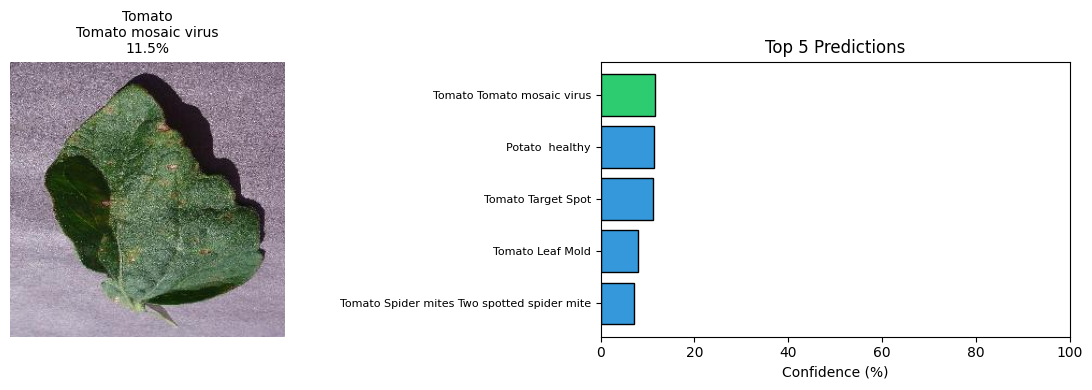

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import os
import random
from PIL import Image

def predict_single_image(image_path):
    # Load and preprocess
    img = Image.open(image_path).convert('RGB')
    img_resized = img.resize(IMG_SIZE)
    arr = np.array(img_resized, dtype=np.float32)
    arr = np.expand_dims(arr, axis=0)  # shape: (1, 224, 224, 3)

    # Predict
    probs   = model.predict(arr, verbose=0)[0]
    top5_idx = np.argsort(probs)[::-1][:5]

    pred_class = CLASS_NAMES[top5_idx[0]]
    confidence = probs[top5_idx[0]] * 100

    # Print results
    print('Image     :', os.path.basename(image_path))
    print('Prediction:', pred_class)
    print('Confidence:', round(confidence, 2), '%')
    if confidence < 60:
        print('WARNING: Low confidence — result may not be reliable')
    print()
    print('Top 5 predictions:')
    for rank, idx in enumerate(top5_idx, 1):
        print('  ' + str(rank) + '. ' + CLASS_NAMES[idx] + '  ' + str(round(probs[idx]*100, 2)) + '%')

    # Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.imshow(img)
    ax1.set_title(pred_class.replace('__', '\n').replace('_', ' ') + '\n' + str(round(confidence, 1)) + '%', fontsize=10)
    ax1.axis('off')

    labels = [CLASS_NAMES[i].replace('__', ' ').replace('_', ' ') for i in top5_idx]
    values = [probs[i] * 100 for i in top5_idx]
    bar_colors = ['#2ecc71'] + ['#3498db'] * 4
    ax2.barh(labels[::-1], values[::-1], color=bar_colors[::-1], edgecolor='black')
    ax2.set_xlabel('Confidence (%)')
    ax2.set_title('Top 5 Predictions')
    ax2.set_xlim(0, 100)
    ax2.tick_params(axis='y', labelsize=8)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'prediction_result.png'), dpi=120)
    plt.show()

# ── Pick a random test image automatically
random_class = random.choice(CLASS_NAMES)
class_test_dir = os.path.join(DATASET_BASE, 'test', random_class)
random_image = os.path.join(class_test_dir, random.choice(os.listdir(class_test_dir)))

print('Testing on random image from class:', random_class)
print()
predict_single_image(random_image)

In [33]:
import tensorflow as tf
import os

print('Exporting to TFLite...')
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]
tflite_model = converter.convert()

with open(TFLITE_PATH, 'wb') as f:
    f.write(tflite_model)

size_mb = round(os.path.getsize(TFLITE_PATH) / 1e6, 2)
print('TFLite model saved:', TFLITE_PATH)
print('Model size        :', size_mb, 'MB')

Exporting to TFLite...
Saved artifact at '/tmp/tmpl1gun025'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_409')
Output Type:
  TensorSpec(shape=(None, 15), dtype=tf.float32, name=None)
Captures:
  134010059920336: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  134010059927056: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  134010059367504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134010059367696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134010059362320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134010059366352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134010059365392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134010059366160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134010059367120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134010059365776: TensorSpec(shape=(), 

In [34]:
import zipfile
import os
from google.colab import files

zip_out = '/content/plant_disease_results.zip'

print('Zipping output files...')
with zipfile.ZipFile(zip_out, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fname in os.listdir(OUTPUT_DIR):
        fpath = os.path.join(OUTPUT_DIR, fname)
        if os.path.isfile(fpath):  # only files, not subfolders
            zf.write(fpath, fname)
            print('  Added:', fname)

size_mb = round(os.path.getsize(zip_out) / 1e6, 2)
print()
print('Zip ready:', zip_out, '(' + str(size_mb) + ' MB)')
print('Downloading now...')
files.download(zip_out)

Zipping output files...
  Added: class_names.json
  Added: log_phase2.csv
  Added: log_phase1.csv
  Added: best_model.keras
  Added: curves_phase1.png
  Added: curves_phase2.png
  Added: best_model_phase1.keras
  Added: model.tflite
  Added: class_distribution.png
  Added: sample_images.png
  Added: best_model_phase2.keras
  Added: prediction_result.png

Zip ready: /content/plant_disease_results.zip (168.22 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>